In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/test.csv")

In [3]:
frames = list(df["frame_num"].unique())


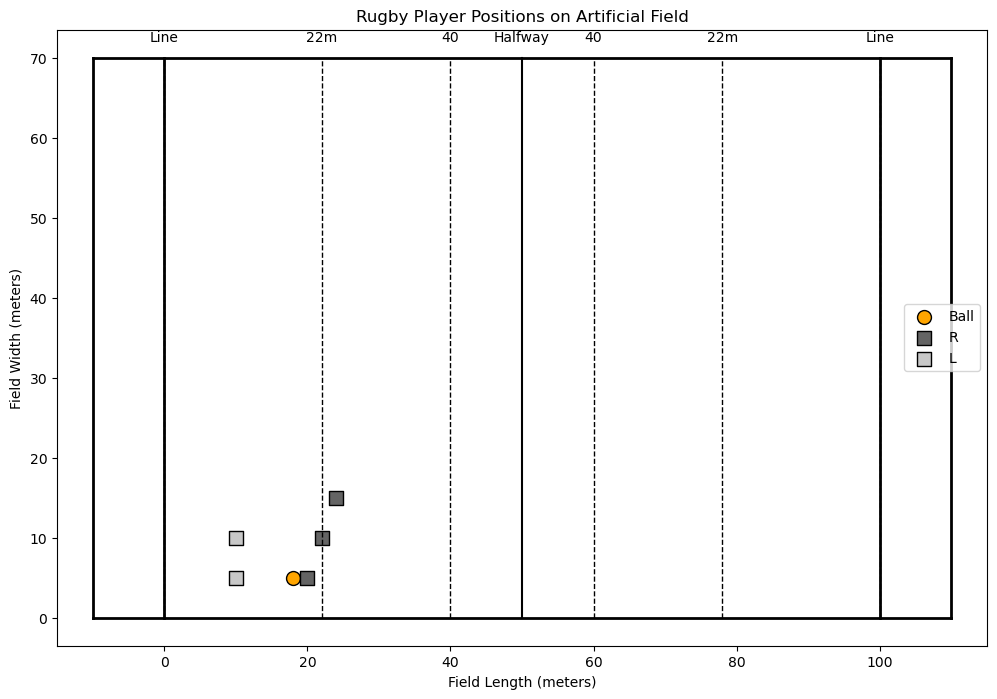

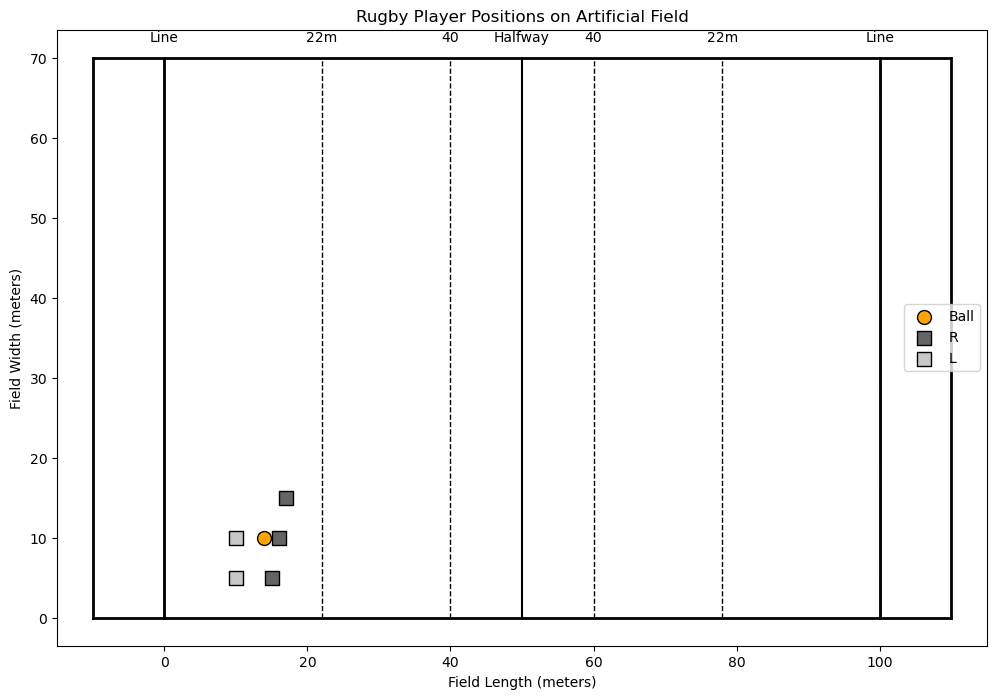

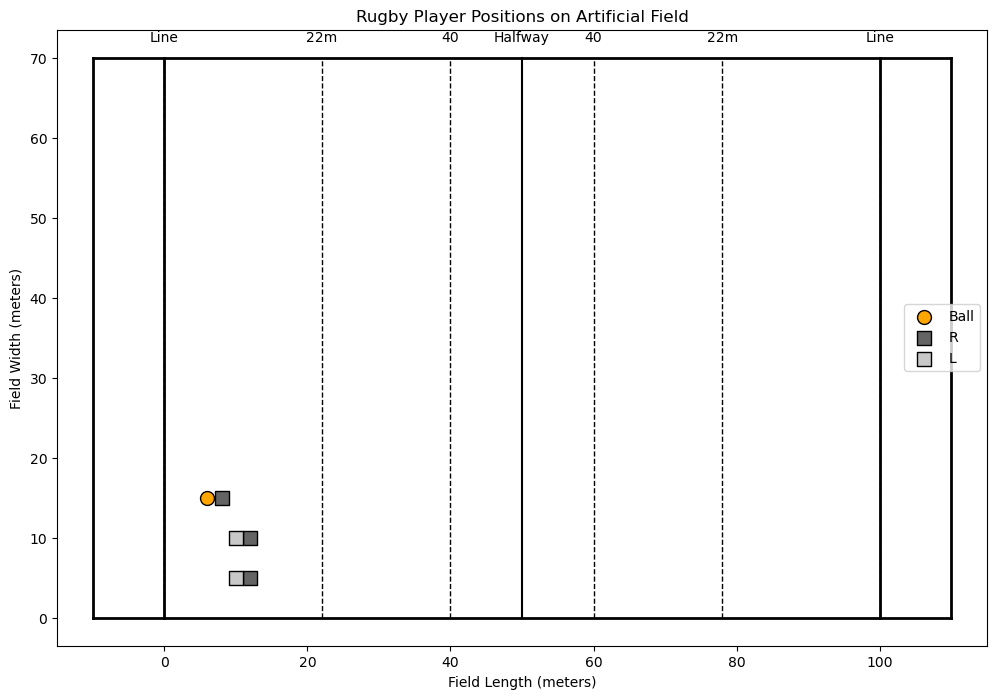

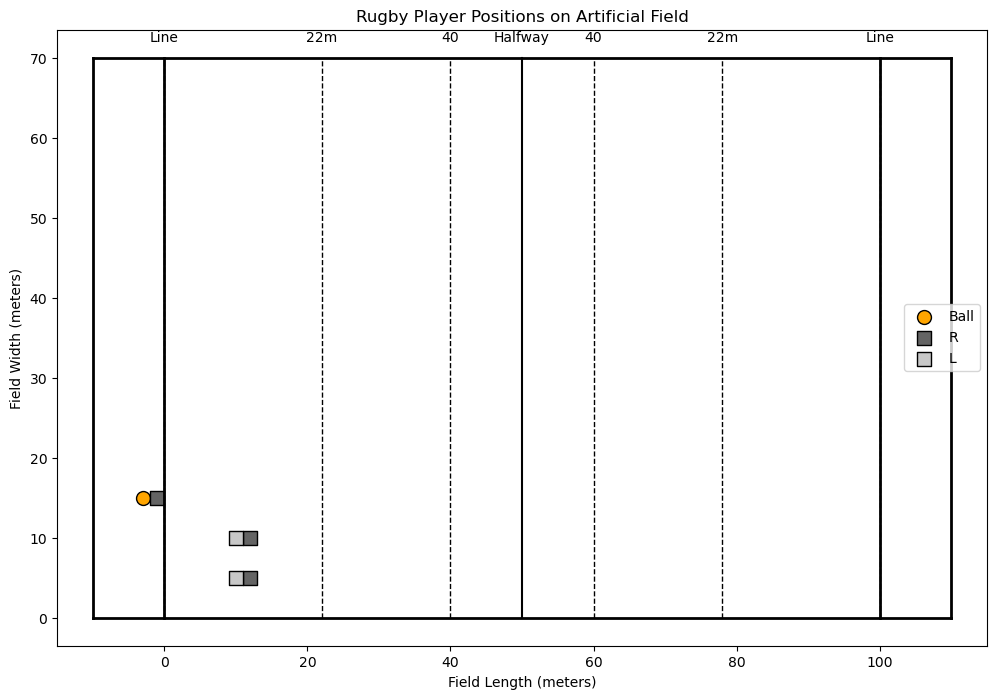

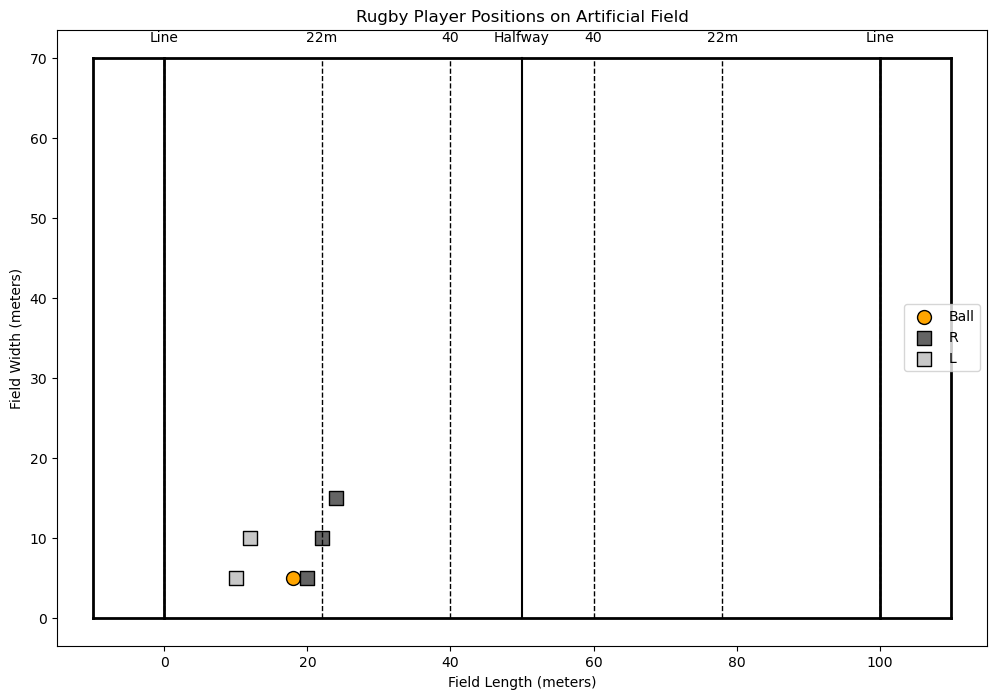

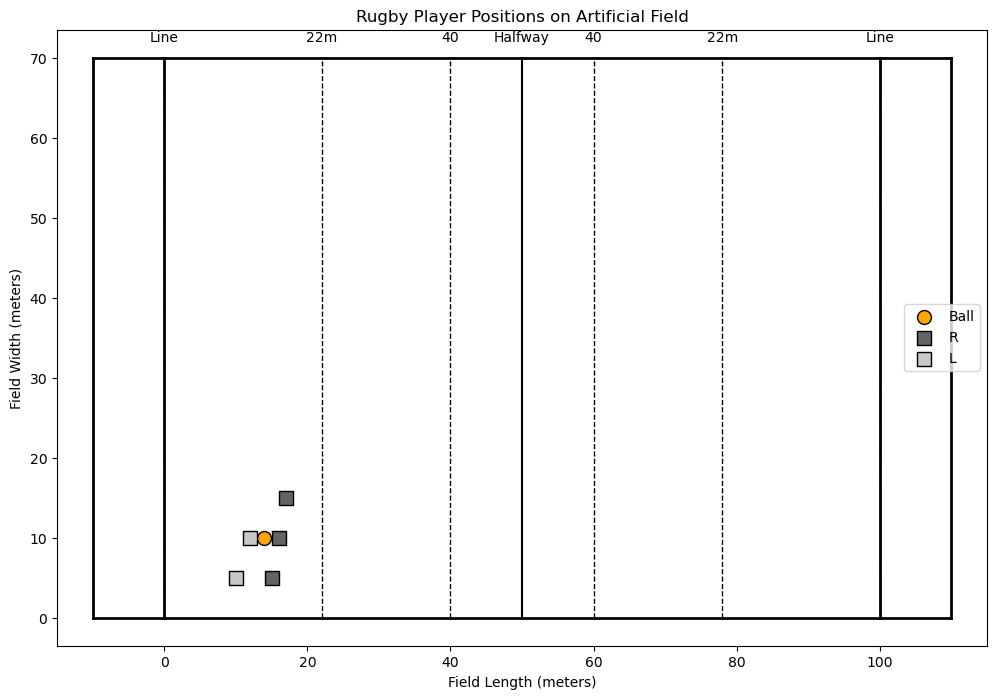

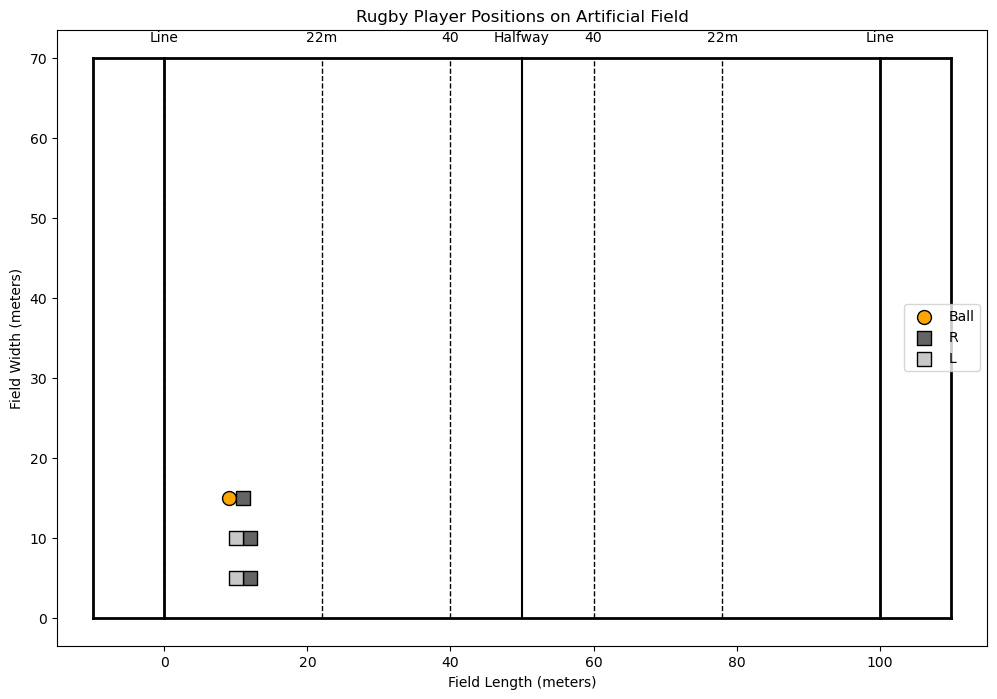

In [5]:
for frame in frames:
    test = df[df["frame_num"] == frame]
    # Rugby field dimensions
    FIELD_LENGTH = 100  # Full field length (goal line to goal line)
    FIELD_WIDTH = 70    # Full field width (sideline to sideline)

    # Create a figure
    fig, ax = plt.subplots(figsize=(12, 8))

    ax.set_xlim(-15, FIELD_LENGTH + 15)

    # Draw field boundaries
    ax.plot([-10, -10], [0, FIELD_WIDTH], 'k-', linewidth=2)  # Left sideline
    ax.plot([0, 0], [0, FIELD_WIDTH], 'k-', linewidth=2)  # Left sideline
    ax.plot([FIELD_LENGTH, FIELD_LENGTH], [0, FIELD_WIDTH], 'k-', linewidth=2)  # Right sideline
    ax.plot([FIELD_LENGTH+10, FIELD_LENGTH+10], [0, FIELD_WIDTH], 'k-', linewidth=2)  # Right sideline
    ax.plot([-10, FIELD_LENGTH+10], [0, 0], 'k-', linewidth=2)  # Bottom (goal line)
    ax.plot([-10, FIELD_LENGTH+10], [FIELD_WIDTH, FIELD_WIDTH], 'k-', linewidth=2)  # Top (goal line)

    # Draw major field lines
    ax.plot([0, 0], [0, FIELD_WIDTH], 'k--', linewidth=1)  # 22m line (left)
    ax.plot([22, 22], [0, FIELD_WIDTH], 'k--', linewidth=1)  # 22m line (left)
    ax.plot([40, 40], [0, FIELD_WIDTH], 'k--', linewidth=1)  # 22m line (left)
    ax.plot([50, 50], [0, FIELD_WIDTH], 'k-', linewidth=1.5)  # Halfway line
    ax.plot([60, 60], [0, FIELD_WIDTH], 'k--', linewidth=1)  # 22m line (left)
    ax.plot([78, 78], [0, FIELD_WIDTH], 'k--', linewidth=1)  # 22m line (right)
    ax.plot([100, 100], [0, FIELD_WIDTH], 'k--', linewidth=1)  # 22m line (right)

    # Label key lines
    ax.text(0, FIELD_WIDTH + 2, "Line", ha='center', fontsize=10, color='black')
    ax.text(22, FIELD_WIDTH + 2, "22m", ha='center', fontsize=10, color='black')
    ax.text(40, FIELD_WIDTH + 2, "40", ha='center', fontsize=10, color='black')
    ax.text(50, FIELD_WIDTH + 2, "Halfway", ha='center', fontsize=10, color='black')
    ax.text(60, FIELD_WIDTH + 2, "40", ha='center', fontsize=10, color='black')
    ax.text(78, FIELD_WIDTH + 2, "22m", ha='center', fontsize=10, color='black')
    ax.text(100, FIELD_WIDTH + 2, "Line", ha='center', fontsize=10, color='black')

    for index, row in test.iterrows():
        team_name = row["team"]
        if team_name == "R":
            team_color = np.array([100,100,100]) / 255
            ax.scatter(row["x_field"], row["y_field"], c=[team_color], s=100, marker='s', edgecolors='black', label=team_name)
        elif team_name == "L":
            team_color = np.array([200,200,200]) / 255
            ax.scatter(row["x_field"], row["y_field"], c=[team_color], s=100, marker='s', edgecolors='black', label=team_name)
        elif team_name == "Ball":
            ax.scatter(row["x_field"], row["y_field"], c='orange', s=100, marker='o', edgecolors='black', label="Ball")

    # Fix legend by removing duplicates
    handles, labels = ax.get_legend_handles_labels()
    unique_labels = dict(zip(labels, handles))  # Remove duplicates
    ax.legend(unique_labels.values(), unique_labels.keys())

    # Titles and labels
    ax.set_xlabel("Field Length (meters)")
    ax.set_ylabel("Field Width (meters)")
    ax.set_title("Rugby Player Positions on Artificial Field")

    # Ensure the plot is displayed
    plt.show()
